# A Neural Algorithm of Artistic Style — Implementation

This notebook implements the optimisation-based neural style transfer algorithm from Gatys, Ecker & Bethge (arXiv:1508.06576, CVPR 2016).

We load a pretrained VGG19, extract content targets from `conv4_2` and style targets as Gram matrices from `conv1_1` through `conv5_1`, then optimise a new image so that it matches the content of one photograph and the style of another painting.

## 1. Setup and imports

In [1]:
import os
import random
import requests
from io import BytesIO

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

IMAGE_SIZE = 256  # pixels on the smaller side; kept modest for free-tier GPUs

Device: cuda


## 2. Image loading helpers

In [2]:
CONTENT_URL = "https://pytorch.org/tutorials/_static/img/neural-style/dancing.jpg"
STYLE_URL = "https://pytorch.org/tutorials/_static/img/neural-style/picasso.jpg"

def download_image(url):
    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        return Image.open(BytesIO(r.content)).convert("RGB")
    except Exception as e:
        print(f"Could not load {url}: {e}")
        return None

def make_synthetic_image(kind="content", size=IMAGE_SIZE):
    """Create a tiny procedural image when the real URLs are unreachable."""
    img = Image.new("RGB", (size, size), color=(200, 200, 200))
    draw = ImageDraw.Draw(img)
    if kind == "content":
        # Simple geometric "house" scene for content
        draw.rectangle([0, size//2, size-1, size-1], fill=(100, 150, 200))  # sky
        draw.polygon([(size//4, size//2), (size//2, size//4), (3*size//4, size//2)], fill=(180, 80, 60))
        draw.rectangle([size//3, size//2, 2*size//3, 3*size//4], fill=(210, 180, 140))
    else:
        # Colourful patches as a fake painting style
        np.random.seed(SEED)
        for _ in range(60):
            x0, y0 = np.random.randint(0, size-30, size=2)
            x1, y1 = x0 + np.random.randint(10, 40), y0 + np.random.randint(10, 40)
            color = tuple(np.random.randint(0, 255, size=3).tolist())
            draw.ellipse([x0, y0, x1, y1], fill=color)
    return img

def load_image(source, kind="content"):
    if isinstance(source, str) and source.startswith("http"):
        img = download_image(source)
        if img is None:
            img = make_synthetic_image(kind=kind)
    else:
        img = make_synthetic_image(kind=kind)
    return img

content_img = load_image(CONTENT_URL, kind="content")
style_img = load_image(STYLE_URL, kind="style")
print("Content size:", content_img.size, "Style size:", style_img.size)

Content size: (444, 444) Style size: (650, 650)


## 3. Preprocessing and denormalisation

In [3]:
def get_image_size(img):
    w, h = img.size
    if w < h:
        new_w = IMAGE_SIZE
        new_h = int(h * IMAGE_SIZE / w)
    else:
        new_h = IMAGE_SIZE
        new_w = int(w * IMAGE_SIZE / h)
    return new_h, new_w

def resize_and_crop(img):
    target_h, target_w = get_image_size(img)
    img = img.resize((target_w, target_h), Image.LANCZOS)
    # Centre crop to a square of IMAGE_SIZE
    w, h = img.size
    left = (w - IMAGE_SIZE) // 2
    top = (h - IMAGE_SIZE) // 2
    return img.crop((left, top, left + IMAGE_SIZE, top + IMAGE_SIZE))

content_img = resize_and_crop(content_img)
style_img = resize_and_crop(style_img)

imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
imagenet_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)

preprocess = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def denormalize(tensor):
    t = tensor.clone().detach().cpu()
    t = t * imagenet_std.cpu() + imagenet_mean.cpu()
    t = torch.clamp(t, 0, 1)
    return t

content_tensor = preprocess(content_img).unsqueeze(0).to(device)
style_tensor = preprocess(style_img).unsqueeze(0).to(device)
print("Content tensor shape:", content_tensor.shape)
print("Style tensor shape:", style_tensor.shape)

Content tensor shape: torch.Size([1, 3, 256, 256])
Style tensor shape: torch.Size([1, 3, 256, 256])


## 4. VGG19 feature extractor with average pooling

In [4]:
class VGGFeatures(nn.Module):
    """VGG19 feature extractor that returns named convolutional activations."""
    def __init__(self):
        super().__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features
        # Replace MaxPool2d with AvgPool2d as suggested in the paper
        for i, layer in enumerate(vgg):
            if isinstance(layer, nn.MaxPool2d):
                vgg[i] = nn.AvgPool2d(kernel_size=2, stride=2, padding=0)
        self.features = vgg
        self.content_layer = "conv4_2"
        self.style_layers = ["conv1_1", "conv2_1", "conv3_1", "conv4_1", "conv5_1"]
        for param in self.parameters():
            param.requires_grad = False
        self.eval()

    def forward(self, x):
        activations = {}
        layer_names = ["conv1_1", "conv1_2",
                       "conv2_1", "conv2_2",
                       "conv3_1", "conv3_2", "conv3_3", "conv3_4",
                       "conv4_1", "conv4_2", "conv4_3", "conv4_4",
                       "conv5_1", "conv5_2", "conv5_3", "conv5_4"]
        out = x
        name_idx = 0
        for layer in self.features:
            out = layer(out)
            if isinstance(layer, nn.Conv2d):
                name = layer_names[name_idx]
                name_idx += 1
                if name in [self.content_layer] + self.style_layers:
                    activations[name] = out
        return activations

vgg = VGGFeatures().to(device)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


  0%|          | 0.00/548M [00:00<?, ?B/s]

  2%|▏         | 8.75M/548M [00:00<00:06, 91.6MB/s]

  5%|▍         | 27.4M/548M [00:00<00:03, 152MB/s] 

  8%|▊         | 46.1M/548M [00:00<00:03, 172MB/s]

...

 86%|████████▌ | 469M/548M [00:02<00:00, 202MB/s]

 89%|████████▉ | 489M/548M [00:02<00:00, 199MB/s]

 93%|█████████▎| 510M/548M [00:02<00:00, 205MB/s]

 97%|█████████▋| 530M/548M [00:02<00:00, 208MB/s]

100%|██████████| 548M/548M [00:02<00:00, 195MB/s]

## 5. Content and style losses

In [5]:
def gram_matrix(x):
    """Compute the normalised Gram matrix of a feature map."""
    b, c, h, w = x.shape
    features = x.view(b, c, h * w)
    G = torch.bmm(features, features.transpose(1, 2))
    return G / (c * h * w)

def content_loss(gen_features, content_features):
    return 0.5 * torch.mean((gen_features["conv4_2"] - content_features["conv4_2"]) ** 2)

def style_loss(gen_features, style_grams):
    loss = 0.0
    weight = 1.0 / len(style_grams)
    for layer, target_gram in style_grams.items():
        gen_gram = gram_matrix(gen_features[layer])
        loss += weight * torch.mean((gen_gram - target_gram) ** 2)
    return loss

with torch.no_grad():
    content_features = vgg(content_tensor)
    style_features = vgg(style_tensor)
    style_grams = {layer: gram_matrix(style_features[layer]) for layer in vgg.style_layers}
print("Extracted content features and style Gram matrices.")

Extracted content features and style Gram matrices.


## 6. Optimisation loop

In [6]:
# Start from the content image plus a little noise (a common practical choice)
input_tensor = content_tensor.clone().detach()
input_tensor = input_tensor + torch.randn_like(input_tensor) * 0.02
input_tensor = torch.clamp(input_tensor, -2.5, 2.5)
input_tensor.requires_grad_(True)

alpha = 1.0     # content weight
beta = 1e4      # style weight; alpha/beta ~ 1e-4 is style-heavy
num_steps = 300
print_interval = 50

optimizer = optim.LBFGS([input_tensor], lr=1.0, max_iter=20)

run = [0]
while run[0] <= num_steps:
    def closure():
        optimizer.zero_grad()
        # Clamp pixels to a valid normalised range during optimisation
        with torch.no_grad():
            input_tensor.clamp_(-3.0, 3.0)

        gen_features = vgg(input_tensor)
        c_loss = content_loss(gen_features, content_features)
        s_loss = style_loss(gen_features, style_grams)
        total_loss = alpha * c_loss + beta * s_loss
        total_loss.backward()

        run[0] += 1
        if run[0] % print_interval == 0:
            print(f"Step {run[0]:4d} | content: {c_loss.item():.4e} | style: {s_loss.item():.4e} | total: {total_loss.item():.4e}")
        return total_loss
    optimizer.step(closure)

with torch.no_grad():
    input_tensor.clamp_(-3.0, 3.0)

Step   50 | content: 7.4550e-04 | style: 4.6427e-07 | total: 5.3882e-03


Step  100 | content: 6.1228e-04 | style: 1.7992e-07 | total: 2.4115e-03


Step  150 | content: 3.9855e-04 | style: 9.6631e-08 | total: 1.3649e-03


Step  200 | content: 3.0591e-04 | style: 8.0564e-08 | total: 1.1116e-03


Step  250 | content: 2.7084e-04 | style: 7.2620e-08 | total: 9.9704e-04


Step  300 | content: 2.5015e-04 | style: 6.7493e-08 | total: 9.2509e-04


## 7. Visualise the results

<Figure size 640x480 with 0 Axes>

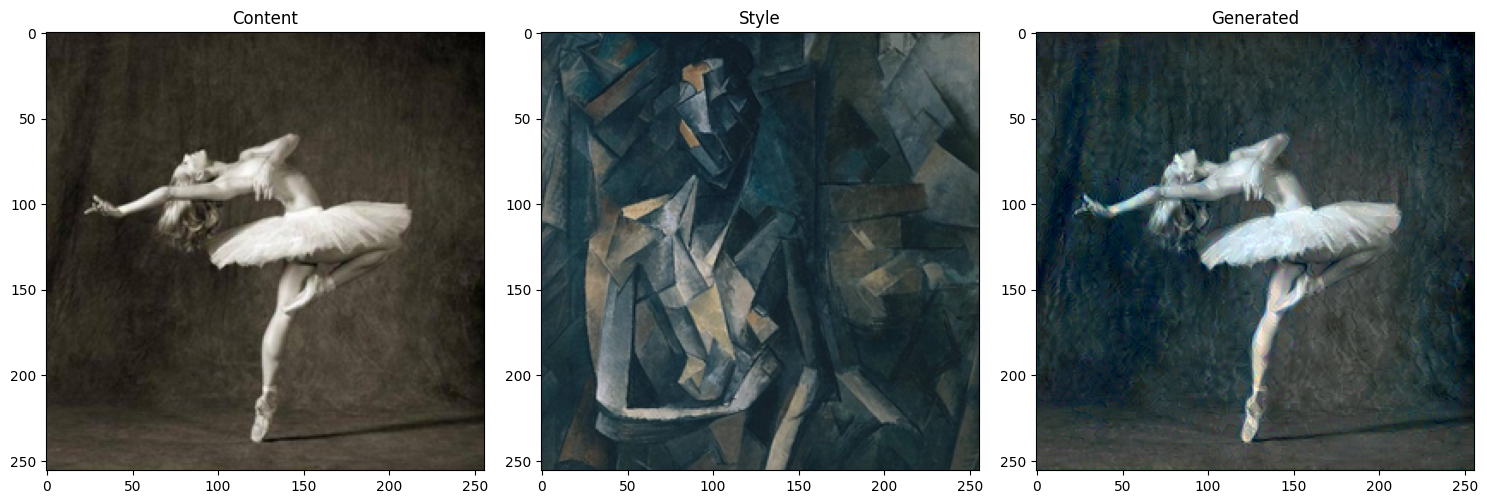

In [7]:
def tensor_to_pil(tensor):
    t = denormalize(tensor).squeeze(0)
    return T.ToPILImage()(t)

for ax in plt.gcf().axes:
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(content_img)
axes[0].set_title("Content")
axes[1].imshow(style_img)
axes[1].set_title("Style")
axes[2].imshow(tensor_to_pil(input_tensor))
axes[2].set_title("Generated")
plt.tight_layout()
plt.show()


## 8. What the notebook demonstrates

- A pretrained VGG19 can be repurposed as a feature extractor; only its convolutional layers matter here.
- Content is captured by the feature map at `conv4_2`.
- Style is captured by the Gram matrices of correlations between filter responses at multiple layers.
- The generated image is the only trainable variable; LBFGS minimises `alpha * content_loss + beta * style_loss`.
- This reproduces the core idea of the paper: separate and recombine content and style in natural images.

In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
